# 1. EDA — KBO 40년 (1982~2021) 팀 데이터 첫 탐색

## 왜 EDA부터?
모델을 만들기 전에 **데이터가 어떻게 생겼는지** 먼저 알아야 합니다. 예를 들어:
- 행 수가 너무 적지는 않나? (모델 학습 가능?)
- 결측치는 어디에 있나?
- 분포가 정상적인가? (ERA가 음수면 데이터 오류)
- 시간에 따라 추세가 있나? (DH 도입, 공인구 변화 등 환경 변화 반영)

이걸 안 하고 모델부터 만들면 "왜 결과가 이상하지" 디버깅에 며칠 날립니다.

## 오늘 노트북에서 할 일
1. 타격/투수 두 CSV 로드 + 정합성 확인
2. 시즌 범위, 팀 개수 점검 (22팀의 정체)
3. 40년 KBO 추세 시각화 — ERA, OPS, 홈런
4. 팀-시즌 분포로 "역사적으로 좋은 성적"의 기준 잡기 (= 백분위 카드의 토대)
5. 스탯과 승수의 상관관계 — 예측 모델에 어떤 피처가 의미 있을지 미리 보기

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data import loader

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지 (Windows)
plt.rcParams['axes.unicode_minus'] = False

## 1) 데이터 로드

로더가 `data/raw/`의 CSV를 읽어 컬럼명을 캐노니컬(`avg`, `era`, `team` 등)로 통일해줍니다. 원본이 한글이든 영문이든 상관없음.

In [2]:
bat = loader.load_batting(PROJECT_ROOT / 'data' / 'raw' / 'kbo_team_batting.csv')
pit = loader.load_pitching(PROJECT_ROOT / 'data' / 'raw' / 'kbo_team_pitching.csv')

print(f'타격: {bat.shape[0]}행 × {bat.shape[1]}컬럼')
print(f'투수: {pit.shape[0]}행 × {pit.shape[1]}컬럼')
print(f'시즌: {bat["year"].min()}~{bat["year"].max()}')

타격: 323행 × 27컬럼
투수: 323행 × 34컬럼
시즌: 1982~2021


## 2) 두 테이블 정합성 점검

타격과 투수는 같은 (팀, 연도) 키로 매칭돼야 합니다. 한쪽에만 있는 행이 있으면 데이터 결함.

In [3]:
bat_keys = set(zip(bat['year'], bat['team']))
pit_keys = set(zip(pit['year'], pit['team']))

only_bat = bat_keys - pit_keys
only_pit = pit_keys - bat_keys

print(f'양쪽에 모두 있는 (연도, 팀): {len(bat_keys & pit_keys)}')
print(f'타격에만 있음: {len(only_bat)}  →  {sorted(only_bat)[:3] if only_bat else ""}')
print(f'투수에만 있음: {len(only_pit)}  →  {sorted(only_pit)[:3] if only_pit else ""}')

양쪽에 모두 있는 (연도, 팀): 323
타격에만 있음: 0  →  
투수에만 있음: 0  →  


## 3) 팀 22개? — 같은 프랜차이즈의 리네임

KBO는 10팀인데 22개로 나옴. 40년 동안 모기업이 바뀌면서 팀 이름이 여러 번 변한 것.

In [4]:
team_years = bat.groupby('team')['year'].agg(['min', 'max', 'count']).sort_values('min')
team_years.columns = ['첫_시즌', '마지막_시즌', '시즌_수']
team_years

,첫_시즌,마지막_시즌,시즌_수
team,,,
Haitai Tigers,1982,2000,19
OB Bears,1982,1998,17
Lotte Giants,1982,2021,40
MBC Blue Dragons,1982,1989,8
Sammi Superstars,1982,1984,3
Samsung Lions,1982,2021,40
Chungbo Pintos,1985,1987,3
Binggre Eagles,1986,1993,8
Pacific Dolphins,1988,1995,8


**관찰**: 어떤 팀이 어느 시점에 사라지고 다른 팀이 그 다음 해에 등장하면 리네임일 확률이 높음. 예) 우리 히어로즈 → 넥센 → 키움.  
Phase 1에서는 **원본 팀명을 그대로 사용**합니다. 프랜차이즈 통합은 Phase 2에서 필요하면 합니다.

## 4) 40년 KBO 추세 — 야구 환경이 어떻게 바뀌었나

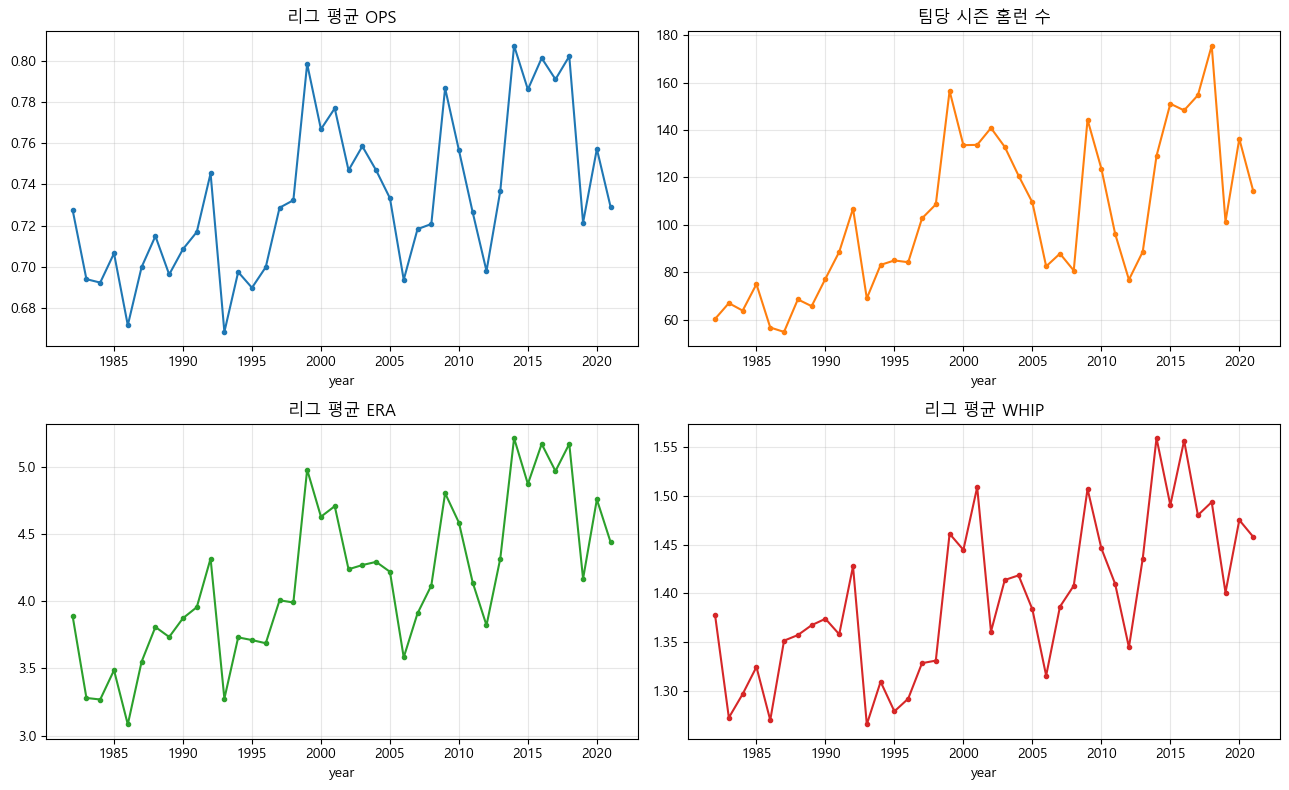

In [5]:
by_year_bat = bat.groupby('year').agg(
    ops_mean=('ops', 'mean'),
    avg_mean=('avg', 'mean'),
    hr_per_team=('hr', 'mean'),
)
by_year_pit = pit.groupby('year').agg(
    era_mean=('era', 'mean'),
    whip_mean=('whip', 'mean'),
)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
by_year_bat['ops_mean'].plot(ax=axes[0, 0], marker='o', ms=3, title='리그 평균 OPS')
by_year_bat['hr_per_team'].plot(ax=axes[0, 1], marker='o', ms=3, color='C1', title='팀당 시즌 홈런 수')
by_year_pit['era_mean'].plot(ax=axes[1, 0], marker='o', ms=3, color='C2', title='리그 평균 ERA')
by_year_pit['whip_mean'].plot(ax=axes[1, 1], marker='o', ms=3, color='C3', title='리그 평균 WHIP')
for ax in axes.flat: ax.grid(alpha=0.3); ax.set_xlabel('year')
plt.tight_layout()

**왜 중요한가**:  
OPS·ERA의 절대값은 시즌마다 다릅니다. 예) 2014년은 타고투저(공인구·DH·구장 영향 등)로 리그 OPS가 솟구쳤음.  
**이게 백분위 평가에 영향**: 0.800 OPS가 2014에는 평범했지만 1985에는 슈퍼스타급. 같은 "리그 내 상대 위치"로 보려면 **연도별 표준화(z-score)** 가 필요할 수 있음 — Phase 1 후반에 검토.

## 5) 팀-시즌 OPS·ERA 분포 (= 백분위 카드의 기반)

"팀 시즌 카드"는 결국 "이 팀-시즌의 OPS는 역사 전체 분포에서 어디인가"를 보여주는 것. 분포부터 봅니다.

OPS: 평균 0.737, 표준편차 0.053, 범위 0.595~0.891
ERA: 평균 4.21, 표준편차 0.75, 범위 2.54~6.35


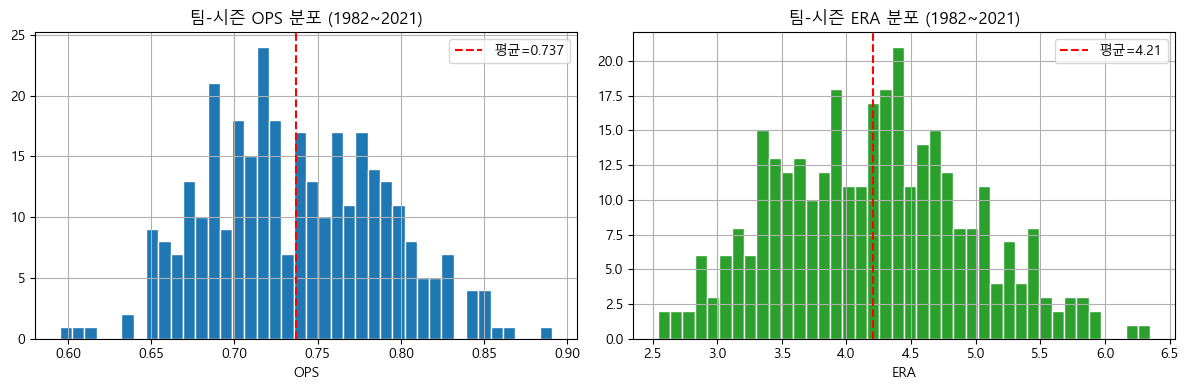

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bat['ops'].hist(bins=40, ax=axes[0], edgecolor='white')
axes[0].axvline(bat['ops'].mean(), color='red', linestyle='--', label=f'평균={bat["ops"].mean():.3f}')
axes[0].set_title('팀-시즌 OPS 분포 (1982~2021)'); axes[0].set_xlabel('OPS'); axes[0].legend()

pit['era'].hist(bins=40, ax=axes[1], edgecolor='white', color='C2')
axes[1].axvline(pit['era'].mean(), color='red', linestyle='--', label=f'평균={pit["era"].mean():.2f}')
axes[1].set_title('팀-시즌 ERA 분포 (1982~2021)'); axes[1].set_xlabel('ERA'); axes[1].legend()
plt.tight_layout()

print(f'OPS: 평균 {bat["ops"].mean():.3f}, 표준편차 {bat["ops"].std():.3f}, 범위 {bat["ops"].min():.3f}~{bat["ops"].max():.3f}')
print(f'ERA: 평균 {pit["era"].mean():.2f}, 표준편차 {pit["era"].std():.2f}, 범위 {pit["era"].min():.2f}~{pit["era"].max():.2f}')

## 6) "가장 좋았던 팀 시즌" 미리보기

Phase 1의 "팀 시즌 카드"가 어떤 느낌일지 손맛 보기. 타격+투수 합쳐서 OPS 백분위, ERA 백분위, 승률 계산.

In [7]:
merged = bat.merge(
    pit[['year', 'team', 'w', 'l', 'era', 'whip']],
    on=['year', 'team'], how='inner',
)
merged['win_pct'] = merged['w'] / (merged['w'] + merged['l'])
merged['ops_pctile'] = merged['ops'].rank(pct=True) * 100
merged['era_pctile'] = (1 - merged['era'].rank(pct=True)) * 100  # ERA는 낮을수록 좋음
merged['win_pctile'] = merged['win_pct'].rank(pct=True) * 100

top10 = merged.nlargest(10, 'win_pct')[
    ['year', 'team', 'w', 'l', 'win_pct', 'ops', 'ops_pctile', 'era', 'era_pctile']
].reset_index(drop=True)
top10.style.format({
    'win_pct': '{:.3f}', 'ops': '{:.3f}', 'ops_pctile': '{:.1f}',
    'era': '{:.2f}', 'era_pctile': '{:.1f}'
})

,year,team,w,l,win_pct,ops,ops_pctile,era,era_pctile
0,1985,Samsung Lions,77,32,0.706,0.771,71.4,2.97,95.5
1,1982,OB Bears,56,24,0.700,0.762,66.1,3.19,91.2
2,2000,Hyundai Unicorns,91,40,0.695,0.848,98.5,3.64,74.3
3,1982,Samsung Lions,53,26,0.671,0.739,53.7,2.70,99.1
4,2008,SK Wyverns,83,43,0.659,0.765,68.3,3.22,90.4
5,1993,Haitai Tigers,81,42,0.659,0.698,25.2,2.92,96.3
6,1986,Samsung Lions,70,37,0.654,0.744,57.1,2.95,96.0
7,1992,Binggre Eagles,81,43,0.653,0.782,79.1,3.68,72.8
8,1991,Haitai Tigers,79,42,0.653,0.768,70.3,2.89,97.1
9,2016,Doosan Bears,93,50,0.650,0.851,99.1,4.45,35.8


위 표가 바로 **팀 시즌 카드의 원형**입니다. Streamlit에서는 한 시즌을 골라 이 정보를 카드처럼 보여주게 됩니다.

## 7) 스탯과 승수의 상관관계 — 예측 모델 직관

승패 예측 모델을 만들기 전에 "어떤 스탯이 승수와 잘 상관되는지" 봅니다. 상관계수가 높은 피처가 예측에 유용할 가능성이 큼.

whip   -0.532612
era    -0.520547
so     -0.090868
bb      0.223702
hr      0.302710
r       0.380117
slg     0.463611
avg     0.489076
ops     0.507547
obp     0.534782
Name: win_pct, dtype: float64

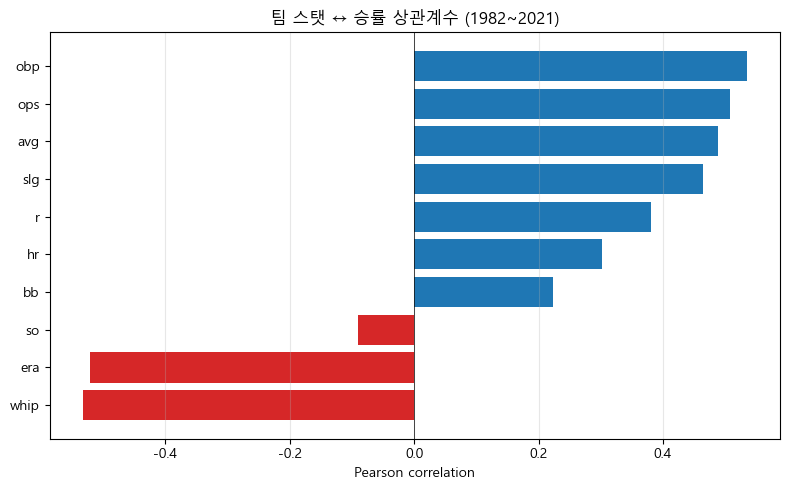

In [8]:
features = ['ops', 'avg', 'obp', 'slg', 'hr', 'r', 'so', 'bb', 'era', 'whip']
corr = merged[features + ['win_pct']].corr()['win_pct'].drop('win_pct').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['C3' if v < 0 else 'C0' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', lw=0.5)
ax.set_title('팀 스탯 ↔ 승률 상관계수 (1982~2021)')
ax.set_xlabel('Pearson correlation')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
corr

**해석**:  
- OPS·OBP·SLG가 승률과 양의 상관 → 공격이 강할수록 승리.  
- ERA·WHIP는 음의 상관 → 평균자책점·WHIP이 낮을수록 승리 (당연하지만 데이터로 확인).  
- 한 스탯의 영향이 ~0.7 정도면 꽤 강한 신호. 다중 회귀로 묶으면 더 좋아짐.

## 다음 단계 (2주차로 이어짐)

- [x] 데이터 정합성 확인
- [x] 40년 추세 파악 (시즌별 환경 다름 → 표준화 고려)
- [x] 백분위 카드의 토대 (OPS·ERA·승률 백분위)
- [x] 예측 피처 후보 식별 (OPS, OBP, SLG, ERA, WHIP)
- [ ] **2주차**: `src/features/`에 피처 엔지니어링 함수 (연도 정규화, 두 팀 매치업 피처)
- [ ] **2주차**: `src/models/`에 베이스라인 로지스틱 회귀 + 시간 분할 검증
- [ ] **3주차~**: Streamlit으로 화면 만들기